In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import duckdb

import seaborn as sns
 
ACCENT, GREY, LIGHT = "#1F6F8B", "#9AA8B3", "#C9D6DC"
PAIR = [ACCENT, GREY]
sns.set_theme(style="whitegrid", context="notebook", rc={"figure.figsize": (8, 4.2),
              "axes.spines.top": False, "axes.spines.right": False})
 
def hbar(data, y, x, ax, fmt="{:,.0f}", color=ACCENT):
    """Horizontal seaborn bar chart in the frame's order, with value labels."""
    sns.barplot(data=data, y=y, x=x, ax=ax, color=color, orient="h", order=list(data[y]))
    ax.bar_label(ax.containers[0], labels=[fmt.format(v) for v in data[x]], padding=3, fontsize=8)
    ax.set_xlim(0, data[x].max() * 1.18)
    ax.set_ylabel("")
 
def paired_share(data, cat, cols, names, ax):
    """Two percentage columns side by side per category (e.g. % repos vs % files)."""
    long = data.melt(id_vars=cat, value_vars=cols, var_name="measure", value_name="pct")
    long["measure"] = long.measure.map(dict(zip(cols, names)))
    sns.barplot(data=long, x=cat, y="pct", hue="measure", palette=PAIR, ax=ax, order=list(data[cat]))
    for cont in ax.containers:
        ax.bar_label(cont, fmt="%.1f", fontsize=8)
    ax.set_ylabel("%"); ax.legend(title="")

from pathlib import Path

def _abs_parquet(rel):
    """Resolve a path relative to src/notebooks and return the absolute parquet path."""
    here = Path.cwd().resolve()
    data = None
    for candidate in (here, *here.parents):
        if (candidate / 'src' / 'data').is_dir() and (candidate / 'src' / 'notebooks').is_dir():
            data = candidate / 'src' / 'data'
            break
        if candidate.name == 'notebooks' and (candidate.parent / 'data').is_dir():
            data = (candidate.parent / 'data').resolve()
            break
    if data is None:
        raise FileNotFoundError(f'Could not locate src/data from {here}')
    path = (data / rel.removeprefix('../data/')).resolve()
    matches = list(path.parent.glob(path.name)) if '*' in path.name else ([path] if path.is_file() else [])
    if not matches:
        raise FileNotFoundError(path)
    return str(path)

repos_path = _abs_parquet('../data/gitskills_data/data/repos/*.parquet')
artifacts_path = _abs_parquet('../data/gitskills_data/data/artifacts/*.parquet')
artifact_siblings_path = _abs_parquet('../data/gitskills_data/data/artifact_siblings/*.parquet')
mining_runs_path = _abs_parquet('../data/gitskills_data/data/mining_runs/*.parquet')
skill_features_path = _abs_parquet('../data/generated_data/skill_features.parquet')
file_agents_path = _abs_parquet('../data/generated_data/file_agents.parquet')
repo_profile_path = _abs_parquet('../data/generated_data/repo_profile.parquet')

con = duckdb.connect(database=':memory:')

## Repositories that host skills

One row per repository that contains at least one `SKILL.md`. Built in `db/repos.sql` as `repo_profile.parquet`: file counts come from artifacts, stars, license, language, and age come from the repos table. `copy_share` is the fraction of a repo's skill files whose text is represented elsewhere (`dedup_primary = 0`).

### Licenses

In [2]:
licenses = con.execute(f"""
SELECT coalesce(nullif(license, ''), '(none)') AS license, COUNT(*) AS repos,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct_repos
FROM read_parquet('{repos_path}')
GROUP BY 1 ORDER BY repos DESC LIMIT 10
""").df()
licenses

,license,repos,pct_repos
0,(none),156981,55.6
1,MIT,85309,30.2
2,Apache-2.0,16889,6.0
3,NOASSERTION,12239,4.3
4,GPL-3.0,3634,1.3
5,AGPL-3.0,3093,1.1
6,BSD-3-Clause,808,0.3
7,Unlicense,433,0.2
8,GPL-2.0,407,0.1
9,MPL-2.0,393,0.1


#### Repository profile

In [2]:
repo_profile = con.execute(f"""
SELECT COUNT(*)                                   AS repos,
       COUNT(DISTINCT owner)                      AS owners,
       median(stars)                              AS median_stars,
       ROUND(AVG((stars = 0)::INT), 3)            AS share_0_stars,
       ROUND(AVG((stars >= 100)::INT), 3)         AS share_100plus_stars,
       ROUND(AVG(is_fork::INT), 3)                AS share_forks,
       ROUND(AVG((license IS NOT NULL AND license <> '')::INT), 3) AS share_with_license
FROM read_parquet('{repo_profile_path}')
""").df()
repo_profile.T.rename(columns={0: "value"})

,value
repos,282200.000
owners,195841.000
median_stars,0.000
share_0_stars,0.593
share_100plus_stars,0.041
share_forks,0.000
share_with_license,0.444


Skills are spread across 282,200 repositories owned by 195,841 accounts
(about 1.4 repositories per owner). Most are small, personal projects: the
median repository has no stars, 59.3% have none, and only 4.1% have 100 or
more. Fewer than half (44.4%) declare a license, which limits how the skills
in the rest may legally be reused. Forks are effectively absent because
GitHub code search excludes them by default, so the dataset covers original
repositories only; fork-based propagation cannot be studied from it.

## Owner concentration: do a few accounts publish most distinct skills?

In [3]:
owners = con.execute(f"""
WITH o AS (
  SELECT r.owner, COUNT(*) AS distinct_skills
  FROM read_parquet('{artifacts_path}') a
  JOIN read_parquet('{repos_path}') r ON r.full_name = a.repo_full_name
  WHERE a.dedup_primary = 1
  GROUP BY 1
), ranked AS (
  SELECT distinct_skills,
         SUM(distinct_skills) OVER (ORDER BY distinct_skills DESC ROWS UNBOUNDED PRECEDING) AS cum,
         ROW_NUMBER() OVER (ORDER BY distinct_skills DESC) AS rnk,
         COUNT(*) OVER () AS n_owners, SUM(distinct_skills) OVER () AS total
  FROM o
)
SELECT rnk AS top_owners, ROUND(100.0 * rnk / n_owners, 2) AS pct_of_owners,
       ROUND(100.0 * cum / total, 1) AS pct_of_distinct_skills
FROM ranked WHERE rnk IN (10, 100, 1000, 10000) OR rnk = n_owners
ORDER BY rnk
""").df()
owners

,top_owners,pct_of_owners,pct_of_distinct_skills
0,10,0.01,11.9
1,100,0.06,24.1
2,1000,0.58,37.8
3,10000,5.78,62.1
4,172863,100.00,100.0


#### How many skill files does a repo hold?

In [3]:
files_per_repo = con.execute(f"""
SELECT size_tier, MIN(files) AS sort_key,
       COUNT(*)                                          AS repos,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct_repos,
       SUM(files)                                        AS files,
       ROUND(100.0 * SUM(files) / SUM(SUM(files)) OVER (), 1) AS pct_files
FROM read_parquet('{repo_profile_path}')
GROUP BY 1 ORDER BY sort_key
""").df()
files_per_repo

,size_tier,sort_key,repos,pct_repos,files,pct_files
0,1,1,121427,43.0,121427.0,3.2
1,2-5,2,86086,30.5,261405.0,6.9
2,6-20,6,53915,19.1,556375.0,14.7
3,21-100,21,17396,6.2,690875.0,18.2
4,101-1000,101,3064,1.1,774417.0,20.4
5,>1000,1006,312,0.1,1392618.0,36.7


Skill files are extremely concentrated. Most repositories hold very few:
43.0% contain a single skill file and 73.5% at most five, yet together they
account for only 10.1% of all files. At the other end, 3,376 repositories
with more than 100 files (1.2% of repositories) hold 57.1% of all skill files,
and the 312 repositories with more than 1,000 files alone hold 36.7%. File-level
statistics are therefore dominated by a few hundred large repositories, while
repository-level statistics describe the long tail of small projects; any
analysis should state which view it takes.

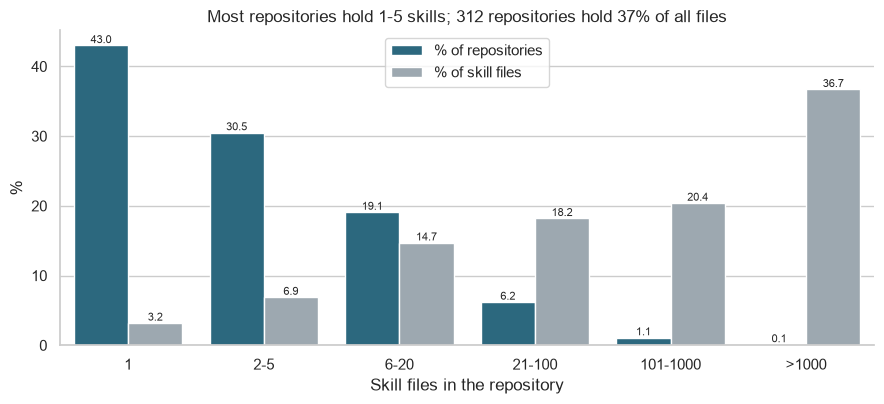

In [4]:
fig, ax = plt.subplots(figsize=(9, 4.2))
paired_share(files_per_repo, "size_tier", ["pct_repos", "pct_files"], ["% of repositories", "% of skill files"], ax)
ax.set_xlabel("Skill files in the repository")
ax.set_title("Most repositories hold 1-5 skills; 312 repositories hold 37% of all files")
plt.tight_layout(); plt.show()

#### Collection vs installer repos among large repos (>100 files)

`copy_share` near 1: most files are copies of skills held elsewhere (installer or aggregator). `copy_share` near 0: this repo holds the representative text (origin or unique collection).

In [5]:
large_repo_kind = con.execute(f"""
SELECT CASE WHEN copy_share >= 0.8 THEN 'mostly copies (>=80%)'
            WHEN copy_share >= 0.2 THEN 'mixed'
            ELSE 'mostly own/unique (<20%)' END AS kind,
       COUNT(*) AS repos, SUM(files) AS files, median(stars) AS median_stars
FROM read_parquet('{repo_profile_path}')
WHERE files > 100
GROUP BY 1 ORDER BY repos DESC
""").df()
large_repo_kind

,kind,repos,files,median_stars
0,mostly copies (>=80%),1565,1096442.0,0.0
1,mostly own/unique (<20%),915,453721.0,2.0
2,mixed,896,616872.0,1.0


Among the 3,376 large repositories, 1,565 consist mostly of copies (80% or
more of their files are represented by another repository's copy) and hold
1,096,442 files, 28.9% of all skill files in the dataset. These are
aggregators, mirrors and installers that copy skills in bulk. Only 915 large
repositories are mostly unique (453,721 files), and 896 are mixed. Large
repositories are also rarely popular: median stars are 0–2 in every group.
Because so many files sit in aggregators, raw file counts overstate how widely
skills are used in real projects.

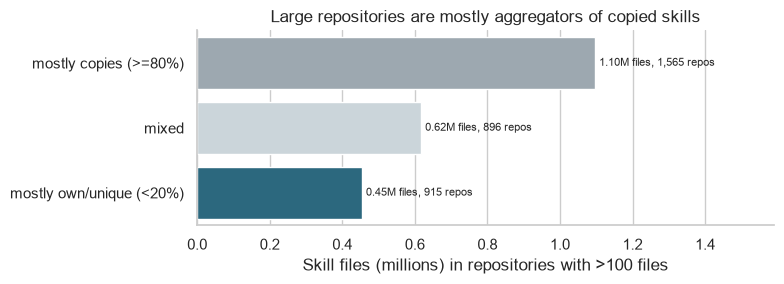

In [6]:
order = ["mostly copies (>=80%)", "mixed", "mostly own/unique (<20%)"]
lk = large_repo_kind.set_index("kind").loc[order].reset_index().assign(files_m=lambda d: d.files / 1e6)
fig, ax = plt.subplots(figsize=(8, 3))
sns.barplot(data=lk, y="kind", x="files_m", orient="h", palette=[GREY, LIGHT, ACCENT], hue="kind",
            order=order, legend=False, ax=ax)
for cont, (_, r) in zip(ax.containers, lk.iterrows()):
    ax.bar_label(cont, labels=[f"{r.files_m:.2f}M files, {r.repos:,} repos"], padding=3, fontsize=8)
ax.set_xlim(0, lk.files_m.max() * 1.45)
ax.set_xlabel("Skill files (millions) in repositories with >100 files"); ax.set_ylabel("")
ax.set_title("Large repositories are mostly aggregators of copied skills")
plt.tight_layout(); plt.show()

#### Largest repositories by skill files

In [7]:
largest_repos = con.execute(f"""
SELECT full_name, files, distinct_skills, copy_share, stars, created_at::DATE AS created
FROM read_parquet('{repo_profile_path}')
ORDER BY files DESC LIMIT 20
""").df()
largest_repos

,full_name,files,distinct_skills,copy_share,stars,created
0,majiayu000/claude-skill-registry-data,172267,89908,0.840,16,2026-02-04
1,David-Li0406/meta-skill-evloving,110654,41975,0.749,0,2026-05-18
2,NeuralBlitz/ncx,63128,44737,0.745,6,2026-02-08
3,gabrielmoreira/agent-skills-mirror,60655,42373,0.830,11,2026-03-23
4,NeuralBlitz/buggy,30308,30308,0.000,3,2026-01-14
5,majiayu000/claude-skill-registry,28460,15316,0.781,498,2025-12-24
6,dvcrn/openclaw-skills-marketplace,22669,21287,0.101,23,2026-03-15
7,Klotzkette/claude-fuer-deutsches-recht,21955,21955,0.000,1332,2026-05-18
8,tools-only/X-Skills,21471,21466,0.288,7,2026-01-31
9,ahmedfawzy8866/arc,18603,3373,0.998,0,2026-07-06


The 20 largest repositories hold 678,468 skill files, 17.9% of the dataset.
The largest, `majiayu000/claude-skill-registry-data`, alone holds 172,267
files (4.5% of all files, 89,908 distinct skills). Nearly all of these
repositories were created in 2026, have few stars, and most are registries,
mirrors or backups with high copy shares (0.75–1.00), e.g.
`agent-skills-mirror`, `openClaw-backup` and `awesome-omni-skill`. A few are
large original collections with little copying, notably
`Klotzkette/claude-fuer-deutsches-recht` (21,955 unique German-law skills,
1,332 stars) and `NeuralBlitz/buggy`. Repositories such as
`jcasnellie69/homelab-config` (12,796 files, only 378 distinct skills) show
heavy in-repo duplication, the same skills repeated across many paths.

#### Repository age
Projects that adopted skills later versus repositories created after the skill format existed.

In [8]:
repo_age = con.execute(f"""
SELECT CASE WHEN created_at < '2025-01-01' THEN 'before 2025'
            WHEN created_at < '2025-10-01' THEN 'Jan-Sep 2025'
            ELSE 'Oct 2025 or later' END            AS created,
       COUNT(*)                                     AS repos,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct_repos,
       median(files)                                AS median_files,
       median(stars)                                AS median_stars
FROM read_parquet('{repo_profile_path}')
GROUP BY 1 ORDER BY MIN(created_at)
""").df()
repo_age

,created,repos,pct_repos,median_files,median_stars
0,before 2025,24923,8.8,2.0,2.0
1,Jan-Sep 2025,14039,5.0,2.0,1.0
2,Oct 2025 or later,243238,86.2,2.0,0.0


Most repositories hosting skills are new: 86.2% were created in October 2025
or later, after the format launched, and exist largely because of skills or
AI-agent work. Only 8.8% (24,923) predate 2025, established projects that
adopted skills later, and another 5.0% were created in early to mid 2025.
Older repositories are slightly more popular (median 2 stars vs 0), but hold
a similar number of skill files (median 2).

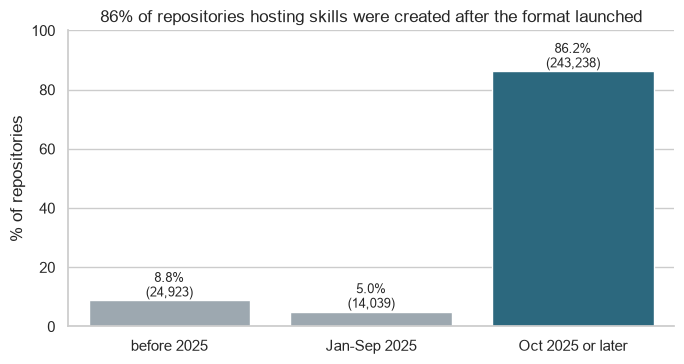

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.8))
sns.barplot(data=repo_age, x="created", y="pct_repos", hue="created", palette=[GREY, GREY, ACCENT],
            order=list(repo_age.created), legend=False, ax=ax)
for cont, (_, r) in zip(ax.containers, repo_age.iterrows()):
    ax.bar_label(cont, labels=[f"{r.pct_repos:.1f}%\n({r.repos:,})"], fontsize=9)
ax.set_ylim(0, 100); ax.set_xlabel(""); ax.set_ylabel("% of repositories")
ax.set_title("86% of repositories hosting skills were created after the format launched")
plt.tight_layout(); plt.show()

#### Primary language of repositories hosting skills

In [10]:
repo_languages = con.execute(f"""
SELECT coalesce(nullif(language, ''), '(none)') AS language,
       COUNT(*) AS repos, ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 1) AS pct_repos
FROM read_parquet('{repo_profile_path}')
GROUP BY 1 ORDER BY repos DESC LIMIT 15
""").df()
repo_languages

,language,repos,pct_repos
0,Python,71801,25.4
1,TypeScript,67104,23.8
2,(none),30116,10.7
3,JavaScript,23938,8.5
4,Shell,19780,7.0
5,HTML,12187,4.3
6,Rust,8371,3.0
7,Go,8094,2.9
8,C#,5168,1.8
9,Java,3172,1.1


The host repositories are mainly Python (25.4%) and TypeScript (23.8%)
projects, followed by JavaScript (8.5%) and Shell (7.0%). One in ten (10.7%)
has no detected language, typical of repositories containing only Markdown,
such as skill collections. The mix reflects where AI coding agents are most
used rather than a preference built into the format.

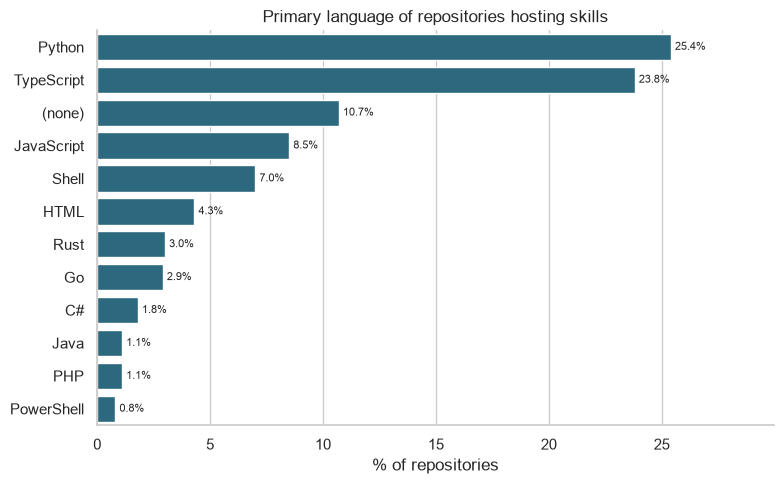

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
hbar(repo_languages.head(12), "language", "pct_repos", ax, fmt="{:.1f}%")
ax.set_xlabel("% of repositories"); ax.set_title("Primary language of repositories hosting skills")
plt.tight_layout(); plt.show()

#### Repositories that exist for skills (by name)

`name_has_skill` matches `skill` in the repo name. `name_is_collection` matches awesome, collection, library, marketplace, registry, or hub. `name_has_agent` matches claude, agent, codex, cursor, copilot, or gemini.

In [12]:
name_flags = con.execute(f"""
SELECT name_has_skill, name_is_collection, name_has_agent,
       COUNT(*) AS repos, SUM(files) AS files,
       ROUND(100.0 * SUM(files) / SUM(SUM(files)) OVER (), 1) AS pct_files
FROM read_parquet('{repo_profile_path}')
GROUP BY 1, 2, 3 ORDER BY files DESC
""").df()
name_flags

,name_has_skill,name_is_collection,name_has_agent,repos,files,pct_files
0,False,False,False,210695,2115819.0,55.7
1,True,False,False,29179,569328.0,15.0
2,False,False,True,26951,391055.0,10.3
3,True,True,True,284,235169.0,6.2
4,True,False,True,8092,229735.0,6.1
5,True,True,False,782,164863.0,4.3
6,False,True,False,5119,71681.0,1.9
7,False,True,True,1098,19467.0,0.5


A quarter of repositories (71,505, 25.3%) have a name that mentions skills,
a collection term (awesome, library, marketplace, registry, hub) or an agent
name, and these hold 44.3% of all skill files. Repositories combining all
three, such as "awesome-claude-skills" style collections, are few (284) but
hold 235,169 files. Name matching is a rough heuristic, but it confirms that a
large share of skill files lives in repositories built to collect or
distribute skills rather than in ordinary software projects.

#### Where do skills live by popularity?

In [13]:
skills_by_stars = con.execute(f"""
SELECT CASE WHEN stars = 0 THEN '0' WHEN stars < 10 THEN '1-9' WHEN stars < 100 THEN '10-99'
            WHEN stars < 1000 THEN '100-999' ELSE '1000+' END AS stars,
       MIN(stars) AS sort_key,
       COUNT(*) AS repos, SUM(files) AS files,
       ROUND(100.0 * SUM(files) / SUM(SUM(files)) OVER (), 1) AS pct_files,
       median(files) AS median_files_per_repo
FROM read_parquet('{repo_profile_path}')
GROUP BY 1 ORDER BY sort_key
""").df()
skills_by_stars

,stars,sort_key,repos,files,pct_files,median_files_per_repo
0,0,0,167008,1747096.0,46.0,2.0
1,1-9,1,80141,1158403.0,30.5,2.0
2,10-99,10,23105,642522.0,16.9,2.0
3,100-999,100,8178,152259.0,4.0,2.0
4,1000+,1000,3768,96837.0,2.6,3.0


Skills live mostly in obscure repositories: 46.0% of skill files are in
repositories with no stars and 76.5% in repositories with fewer than 10.
Repositories with 1,000 or more stars (3,768) hold only 2.6% of files. The
median repository holds 2–3 skill files at every popularity level, so popular
projects do not use more skills; they are simply rare. Popularity-weighted
analyses and file-weighted analyses will therefore describe very different
populations.

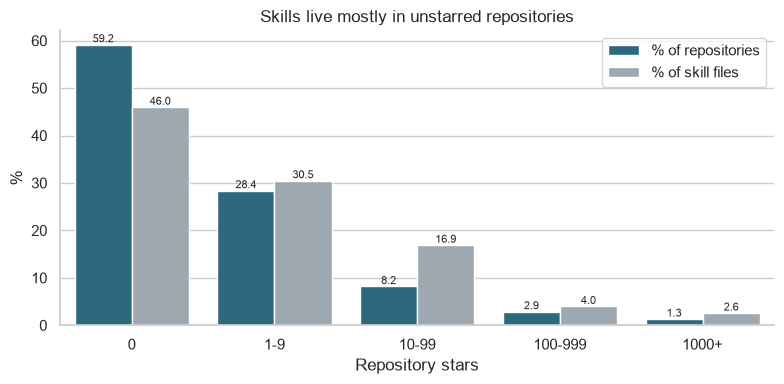

In [14]:
ss = skills_by_stars.assign(pct_repos=lambda d: 100 * d.repos / d.repos.sum())
fig, ax = plt.subplots(figsize=(8, 4))
paired_share(ss, "stars", ["pct_repos", "pct_files"], ["% of repositories", "% of skill files"], ax)
ax.set_xlabel("Repository stars"); ax.set_title("Skills live mostly in unstarred repositories")
plt.tight_layout(); plt.show()

#### Forks

In [15]:
forks = con.execute(f"""
SELECT is_fork, COUNT(*) AS repos, SUM(files) AS files,
       ROUND(AVG(copy_share), 3) AS mean_copy_share
FROM read_parquet('{repo_profile_path}')
GROUP BY 1
""").df()
forks

,is_fork,repos,files,mean_copy_share
0,<NA>,515,7525.0,0.806
1,0,281682,3789584.0,0.216
2,1,3,8.0,0.467


Only 3 repositories are marked as forks, confirming that forks are excluded
by collection. For 515 repositories (7,525 files) the fork flag is missing
because repository metadata could not be fetched; these have a high average
copy share (0.81), consistent with deleted or private aggregator
repositories. They are too few to affect results.